In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Capse_Planck`


In [58]:
# Pkg.add("Random")
# Pkg.add("LinearAlgebra")
# Pkg.add("Turing")
# Pkg.add("PosteriorStats")
# Pkg.add("Distributions")
# Pkg.add("PDMats")
# Pkg.add("LogExpFunctions")
# Pkg.add("Plots")
# Pkg.add("ArviZ")
# Pkg.add("HypothesisTests)
# Pkg.add("MCMCChains")

In [57]:
using Random
using LinearAlgebra
using Turing
using PosteriorStats
using Distributions
using PDMats
using LogExpFunctions
using Plots
using ArviZ
using HypothesisTests
using MCMCChains

### Model Set Up

In [4]:
# Define the Turing model
@model function myfoo(SL, x)
    a ~ Uniform(-10, 10)
    b ~ Uniform(-10, 10)
    μ = a .* x .+ b
    S = Symmetric(SL * SL')
    # Multivariate Normal observation
    y ~ MvNormal(μ, PDMat(Cholesky(SL)))
    return y
end

# Setup synthetic data
Random.seed!(1234)
n = 100
R = rand(LKJCholesky(n, 1))
s = rand(filldist(truncated(TDist(7); lower=0), n))
SL = LowerTriangular(Diagonal(s) * R.L) + 0.2I
S = Symmetric(SL * SL')

x = Array(LinRange(-7, 7, n))
a_true = 1.0
b_true = -3.0
y = rand(MvNormal(a_true .* x .+ b_true, S))

100-element Vector{Float64}:
 -10.69527063150974
 -10.252760841752925
  -9.847087372275812
 -10.560420005646623
  -9.22761985592522
 -11.239895507038792
  -9.411066829212661
  -8.323260236398404
  -9.038885967956297
  -9.149043102923361
  -8.483309180339113
  -8.147104428406067
  -8.123725708107965
   ⋮
   1.9860515660889706
   2.4292640049152223
   6.966580663385802
   5.139938339042853
   3.046206819297155
   4.7766993401301665
   2.9736980732526366
   2.7930330090236244
   4.246023435220193
   3.7467658593142277
   3.3706198309340896
   6.491405961258838

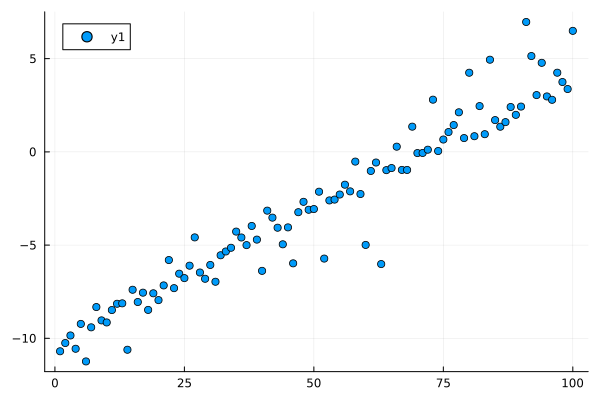

In [5]:
scatter(y)

### Running Chains

In [59]:
num_steps = 2000
num_chains = 8

# Sample from the model using 8 parallel chains
chns = sample(myfoo(SL, x) | (; y), NUTS(), MCMCThreads(), num_steps, num_chains)

# Generate posterior predictions: stochastic realizations from the likelihood
y_pred = predict(myfoo(SL, x), chns)

┌ Info: Found initial step size
└   ϵ = 0.003125
┌ Info: Found initial step size
└   ϵ = 0.0015625
┌ Info: Found initial step size
└   ϵ = 0.003125
┌ Info: Found initial step size
└   ϵ = 0.003125
Sampling (4 threads):  40%|███████████▌                 |  ETA: 0:00:06┌ Info: Found initial step size
└   ϵ = 0.0015625
Sampling (4 threads):  44%|████████████▉                |  ETA: 0:00:06┌ Info: Found initial step size
└   ϵ = 0.0015625
Sampling (4 threads):  48%|█████████████▊               |  ETA: 0:00:05┌ Info: Found initial step size
└   ϵ = 0.003125
Sampling (4 threads):  52%|███████████████▎             |  ETA: 0:00:05┌ Info: Found initial step size
└   ϵ = 0.003125
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:10


Chains MCMC chain (2000×100×8 Array{Float64, 3}):

Iterations        = 1:1:2000
Number of chains  = 8
Samples per chain = 2000
parameters        = y[1], y[2], y[3], y[4], y[5], y[6], y[7], y[8], y[9], y[10], y[11], y[12], y[13], y[14], y[15], y[16], y[17], y[18], y[19], y[20], y[21], y[22], y[23], y[24], y[25], y[26], y[27], y[28], y[29], y[30], y[31], y[32], y[33], y[34], y[35], y[36], y[37], y[38], y[39], y[40], y[41], y[42], y[43], y[44], y[45], y[46], y[47], y[48], y[49], y[50], y[51], y[52], y[53], y[54], y[55], y[56], y[57], y[58], y[59], y[60], y[61], y[62], y[63], y[64], y[65], y[66], y[67], y[68], y[69], y[70], y[71], y[72], y[73], y[74], y[75], y[76], y[77], y[78], y[79], y[80], y[81], y[82], y[83], y[84], y[85], y[86], y[87], y[88], y[89], y[90], y[91], y[92], y[93], y[94], y[95], y[96], y[97], y[98], y[99], y[100]
internals         = 

Summary Statistics
  parameters       mean       std      mcse     ess_bulk     ess_tail      rha ⋯
      Symbol    Float64   Float64   Floa

### Ethan's Manual LOO-PIT

In [7]:
# Extract parameter samples
a_samples = chns[:a].data
b_samples = chns[:b].data

# Compute the mean array for all draws and chains (draws, chains, n)
μ_array = a_samples .* reshape(x, 1, 1, n) .+ b_samples

S_pd = PDMat(Cholesky(SL))

100×100 PDMat{Float64, Matrix{Float64}}:
  0.436879      0.00305262    0.0423074    …  -0.10057       0.00328768
  0.00305262    1.60636      -0.0758373       -0.0699319    -0.0174611
  0.0423074    -0.0758373     0.805467         0.00110232   -0.019853
  0.0100378    -0.098515     -0.0829726        0.0309272     0.0993768
  0.0133542     0.00947728   -0.0428669       -0.059264      0.0706538
 -0.125399     -0.210587     -0.0499662    …   0.222961      0.206429
  0.00209675   -0.0417954    -0.0156933        0.0404137    -0.0321999
  0.0619582     0.0216042     0.0631975        0.0303908     0.000850407
  0.00140741   -0.00310203    0.00109993      -0.00551153   -0.0237851
  0.0259497     0.00605226   -0.021212        -0.0201156    -0.0553939
  0.00249971   -0.00756784    0.00794469   …  -0.0120624     0.0321458
  0.0119072    -0.000999059   0.0150882        0.034446      0.0690517
 -0.00252053    0.00245864    0.00748111       0.00814632   -0.0332587
  ⋮                                

### Log-Likelihoods

In [8]:
idata = from_mcmcchains(
        chns;
        posterior_predictive = y_pred,
        constant_data=(; x),
        observed_data=(; y),
        dims=(x=[:i], y=[:i], pred=[:i]),
)

InferenceData with groups:
  > posterior
  > posterior_predictive
  > sample_stats
  > observed_data
  > constant_data

In [9]:
function inv_diag_cholesky(F::Cholesky)
    if F.uplo == 'U'
        U = inv(UpperTriangular(F.factors))
        return map(Base.Fix1(sum, abs2), eachrow(U))
    else
        L = inv(LowerTriangular(F.factors))
        return map(Base.Fix1(sum, abs2), eachcol(L))
    end
end

function pointwise_normal_loglikelihood!(
    log_like::AbstractArray,
    cov::AbstractMatrix,
    mean::AbstractVector,
    obs::AbstractVector,
)
    F = cholesky(cov)
    c = inv_diag_cholesky(F)
    g = F \ (obs - mean)
    @. log_like = (log(c) -g^2 / c - log(2π)) ./ 2
end

function pointwise_normal_loglikelihood(
    obs::AbstractVector, mean::AbstractArray, cov::AbstractArray
)
    num_sample_dims = ndims(mean) - 1
    @assert num_sample_dims ∈ (1, 2)
    @assert ndims(cov) == num_sample_dims + 2
    @assert length(obs) == 
        size(mean, num_sample_dims + 1) ==
        size(cov, num_sample_dims + 1) == 
        size(cov, num_sample_dims +2)

    cov_dims = ntuple(i -> i + num_sample_dims, 2)
    sample_dims = ntuple(identity, num_sample_dims)

    cov_axes = map(i -> axes(cov, i), cov_dims)
    sample_axes = map(i -> axes(cov, i), sample_dims)
    out_axes = (sample_axes..., cov_axes[1])

    log_like = similar(obs, Base.promote_eltype(obs, mean, cov), out_axes)
    foreach(
        pointwise_normal_loglikelihood!,
        eachslice(log_like; dims=sample_dims),
        eachslice(cov; dims=sample_dims),
        eachslice(mean; dims=sample_dims),
        Iterators.repeated(obs),
    )

    return log_like
end

pointwise_normal_loglikelihood (generic function with 1 method)

In [10]:
# function pointwise_conditional_loglikelihoods(
#     y::AbstractArray{<:Real,N},
#     dists::AbstractArray{
#         <:Distributions.Distribution{<:Distributions.ArrayLikeVariate{N}},M
#     },
# ) where {M,N}
#     T = _loglikelihood_eltype(first(dists), y)
#     sample_dims = ntuple(identity, M)
#     log_like = similar(y, T, (axes(dists)..., axes(y)...))
#     cache = _build_loglikelihood_cache(dists, log_like)
#     for (dist, ll) in zip(dists, eachslice(log_like; dims=sample_dims))
#         pointwise_conditional_loglikelihoods!!(ll, y, dist; cache...)
#     end
#     return log_like
# end

# # Array-variate normal distribution
# function pointwise_conditional_loglikelihoods!!(
#     log_like::AbstractVector{<:Real},
#     y::AbstractVector{<:Real},
#     dist::Distributions.MvNormal,
# )
#     (; μ, Σ) = dist
#     λ = _pd_diag_inv(Σ)
#     g = Σ \ (y - μ)
#     return @. log_like = (log(λ) - g^2 / λ - log2π) / 2
# end
# function pointwise_conditional_loglikelihoods!!(
#     log_like::AbstractVector{<:Real},
#     y::AbstractVector{<:Real},
#     dist::Distributions.MvNormalCanon,
# )
#     (; h, J) = dist
#     λ = LinearAlgebra.diag(J)
#     cov_inv_y = _pdmul(J, y)
#     return @. log_like = (log(λ) - (cov_inv_y - h)^2 / λ - log2π) / 2
# end
# function pointwise_conditional_loglikelihoods!!(
#     log_like::AbstractMatrix{<:Real},
#     y::AbstractMatrix{<:Real},
#     dist::Distributions.MatrixNormal,
# )
#     (; M, U, V) = dist
#     λU = _pd_diag_inv(U)
#     λV = _pd_diag_inv(V)
#     g = U \ (y - M) / V
#     return @. log_like = (log(λU) + log(λV') - g^2 / λU / λV' - log2π) / 2
# end

# # Multivariate log-normal distribution
# function pointwise_conditional_loglikelihoods!!(
#     log_like::AbstractVector{<:Real},
#     y::AbstractVector{<:Real},
#     dist::Distributions.MvLogNormal,
# )
#     logy = log.(y)
#     pointwise_conditional_loglikelihoods!!(log_like, logy, dist.normal)
#     log_like .-= logy
#     return log_like
# end

In [11]:
cov = repeat(reshape(Array(S_pd), 1, 1, n, n), num_steps, num_chains, 1, 1);

In [12]:
log_like = pointwise_normal_loglikelihood(
    idata.observed_data.y,
    µ_array,
    cov,
)

2000×8×100 Array{Float64, 3}:
[:, :, 1] =
 -0.201001   -0.69488   -0.325284  …  -0.504361  -0.488565  -0.527522
 -0.0732362  -1.07924   -0.585928     -0.314232  -0.435125  -0.25773
 -0.0795988  -1.23537   -0.409728     -0.223125  -0.435125  -0.25773
 -0.160701   -0.82942   -0.58378      -0.276601  -0.432359  -0.414179
 -0.671947   -0.776372  -0.56424      -0.404575  -0.503493  -0.414179
 -0.46605    -0.789107  -0.398587  …  -0.183277  -0.304664  -0.44911
 -0.364864   -0.740295  -0.364857     -0.743973  -0.336021  -0.501919
 -0.188666   -0.482827  -0.444531     -0.383672  -0.719391  -0.421916
 -0.33565    -0.610852  -0.444531     -0.733219  -0.719391  -0.497699
 -0.260922   -0.593348  -0.627248     -0.575981  -0.303978  -0.442369
 -0.503456   -0.41075   -0.627248  …  -0.700846  -0.35225   -0.442369
 -0.292416   -0.34956   -0.439237     -0.760199  -0.451408  -0.299069
 -0.154212   -0.576545  -0.51501      -0.661952  -0.451408  -0.303171
  ⋮                                ⋱   ⋮           

In [13]:
idata = merge(
    idata,
    InferenceData(; log_likelihood = namedtuple_to_dataset((; y = log_like))),
)

InferenceData with groups:
  > posterior
  > posterior_predictive
  > log_likelihood
  > sample_stats
  > observed_data
  > constant_data

### PSIS (Pareto Smoothed Importance Sampling)

In [14]:
psis_result = Vector{PSISResult{Float64, Vector{Float64}, Int64, Int64, PSIS.GeneralizedPareto{Float64}}}(undef, n);

In [36]:
for i in 1:n
    log_like_all_chains = vec(idata.log_likelihood[:,:,i][:y])
    psis_result[i] = psis(-log_like_all_chains)
end

In [37]:
log_weights = Array{Float64, 3}(undef, num_steps, num_chains, n)

for i in 1:n
    log_weights_local = psis_result[i].log_weights
    for j in 1:num_chains
        for k in 1:num_steps
            log_weights[k,j,i] = log_weights_local[(j-1)* num_chains + k]
        end
    end
end
log_weights

2000×8×100 Array{Float64, 3}:
[:, :, 1] =
  -9.93247  -9.79782  -9.8478   -9.62938  …   -9.43378   -9.79132   -9.74078
 -10.0602   -9.87254  -9.82453  -9.48985      -9.43378   -9.63067   -9.4861
 -10.0539   -9.63001  -9.88637  -9.61846      -9.55456   -9.4118    -9.57799
  -9.97277  -9.84105  -9.88637  -9.70411      -9.55456  -10.0502    -9.56672
  -9.46152  -9.97926  -9.88637  -9.52539      -9.88544   -9.77097   -9.86865
  -9.66742  -9.83313  -9.81702  -9.54701  …   -9.37031   -9.80181   -9.94889
  -9.7686   -9.79199  -9.66175  -9.62013     -10.0233    -9.73608   -9.83095
  -9.9448   -9.83767  -9.97437  -9.42505      -9.79901   -9.73625   -9.77505
  -9.79782  -9.8478   -9.62938  -9.62935      -9.79132   -9.74078   -9.77187
  -9.87254  -9.82453  -9.48985  -9.47636      -9.63067   -9.4861    -9.88178
  -9.63001  -9.88637  -9.61846  -9.79274  …   -9.4118    -9.57799   -9.73618
  -9.84105  -9.88637  -9.70411  -9.79274     -10.0502    -9.56672   -9.6863
  -9.97926  -9.88637  -9.52539  -9.6

In [17]:
pareto_shapes = Vector{Float64}(undef, n)

for i in 1:n
    pareto_shapes[i] = psis_result[i].pareto_shape
end

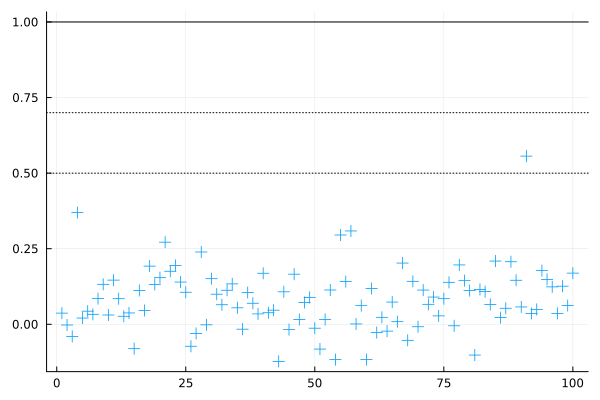

In [18]:
scatter(pareto_shapes; marker =:+, markersize=6, legend = false, linewidth=2)
hline!([0.5,0.7], linestyle=:dot, color =:black)
hline!([1.0], linestyle=:solid, color=:black)

### (PIT) Probability Integral Transfrom

In [19]:
draws = Vector{Vector{Float64}}(undef, num_steps*num_chains)

for i in 1:num_steps
    for j in 1:num_chains
        new_µ = vec(µ_array[i,j,:])
        dist = MvNormal(new_µ, S_pd)
        draws[(i-1)*num_chains + j] = rand(dist)
    end
end

In [21]:
comparison_values = Array{Float64}(undef, n, num_steps)

for j in 1:num_steps
    draw = draws[j]
    data = y

    for i in 1:n
        if draw[i] < data[i]
            comparison_values[i,j] = 1
        else
            comparison_values[i,j] = 0
        end
    end
end

In [22]:
PIT_Values = Vector{Float64}(undef, n)
for i in 1:n
    sum = 0
    for j in 1:num_steps
        sum += comparison_values[i,j]
    end

    PIT_Values[i] = sum / num_steps
end

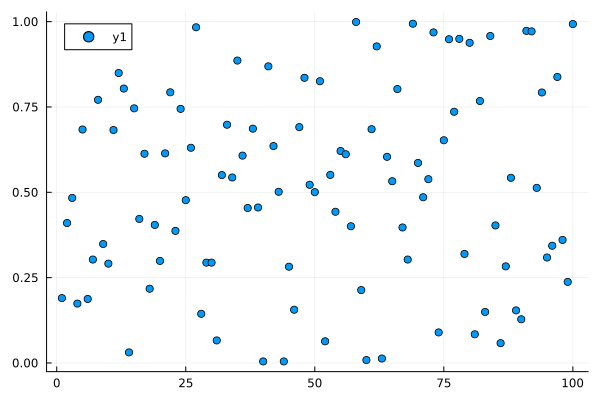

In [23]:
scatter(PIT_Values)

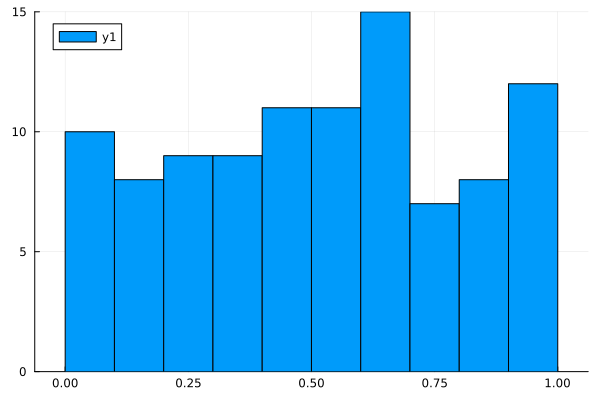

In [24]:
histogram(PIT_Values, bins = 10)

### Comparison of first data point observation and draws

In [25]:
y_pred_array = permutedims(y_pred[[Symbol("y[$i]") for i in 1:n]].value.data, (1, 3, 2))

2000×8×100 Array{Float64, 3}:
[:, :, 1] =
  -9.81773   -9.86023   -9.53843  …   -8.37034   -9.72298  -10.8698
  -9.59014  -11.2634    -9.98215      -9.15977   -8.81979  -10.0559
  -9.79784  -11.318     -9.68713     -11.1563   -10.6198   -10.9067
  -9.2992   -10.0526    -9.2795      -10.355     -9.98834  -10.0526
 -10.3755   -10.6979   -10.8191       -9.08226  -10.0492    -9.74896
  -9.90615   -9.48454  -10.1385   …   -9.37757  -10.6249    -9.57363
 -10.2441   -10.9402   -10.8648       -9.96975  -10.2547   -10.0736
 -10.5556   -11.2717    -8.61369     -10.2186    -9.57058  -10.651
 -10.5465    -8.57924   -9.28432     -11.3273    -9.77297   -9.84204
  -8.79553   -8.74325  -10.9466      -10.0929    -8.88289  -10.9527
 -10.1472   -10.0397   -10.0161   …  -10.8041    -8.58136  -10.9841
 -10.232     -8.4719    -9.37792      -9.97708  -10.6483   -10.476
 -10.9821   -10.2738    -9.7867      -11.5463   -11.0642    -9.3948
   ⋮                              ⋱    ⋮                   
  -9.81232   

In [26]:
y_1_array = []
for i in 1:8
    y_1_array = append!(y_1_array, y_pred_array[:,i,1])
end

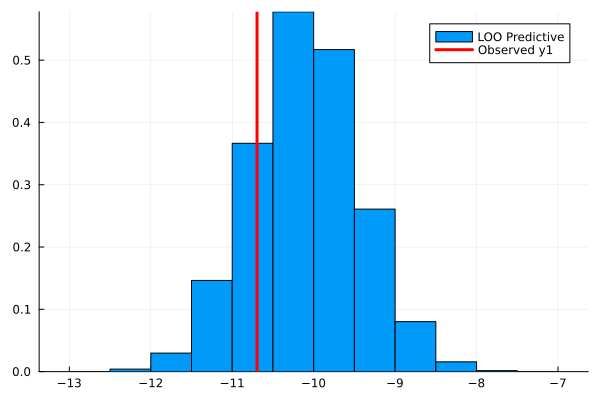

In [27]:
histogram(y_1_array, normalize=:pdf, bins = 20, label="LOO Predictive")
vline!([y[1]], color=:red, linewidth=3, label = "Observed y1")

In [44]:
ks_test_ethan = ExactOneSampleKSTest(PIT_Values, Uniform(0, 1))
pvalue(ks_test_ethan)

0.6509082962856765